In [3]:
#Libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_squared_log_error

Train Shape: (138701, 50)
Test Shape: (15000, 49)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 no

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


______________________________________________________________________


,Missing Count,Missing %
col19,138635,99.952416
col18,138635,99.952416
col5,128320,92.515555
col4,128320,92.515555
col27,123742,89.214930
col28,123742,89.214930
col29,119829,86.393753
col30,119829,86.393753
col13,115296,83.125572
col14,115296,83.125572


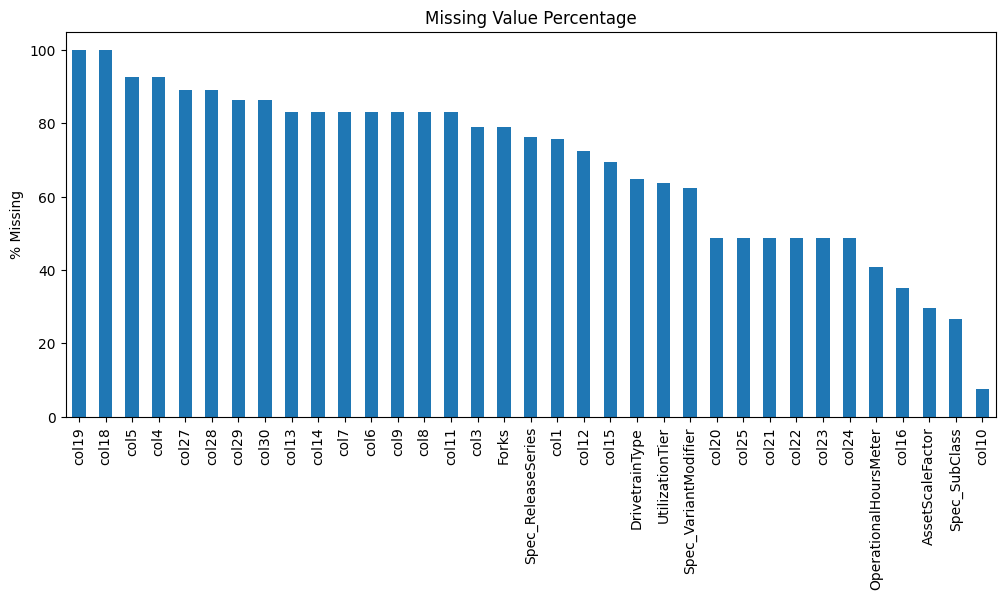

In [4]:
#Eda
TRAIN_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
TEST_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv"

train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.info()
display(train.head())
print("_"*70)

#missing value analysis:
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_percent = (missing / len(train)) * 100
missing_df = pd.DataFrame({"Missing Count": missing,"Missing %": missing_percent})

display(missing_df)
missing_percent.plot(kind="bar", figsize=(12,5))
plt.title("Missing Value Percentage")
plt.ylabel("% Missing")
plt.show()

# Missing value analysis:

**Observation:**
The bar chart shows the percentage of missing values present in each feature of the dataset. Several columns such as col18 and col19 have nearly 100% missing values, while features like OperationalHoursMeter, AssetScaleFactor, and Spec_SubClass also contain a significant amount of missing data. This indicates that the dataset is incomplete and requires preprocessing before model training.

**Interpretation:**
From this analysis, I learned that handling missing values is essential for building an accurate machine learning model. Based on these observations, I filled missing numerical values with the median and categorical values with "Missing" during preprocessing. This ensured that CatBoost, LightGBM, and XGBoost received complete data, allowing the models to train effectively and produce reliable predictions.

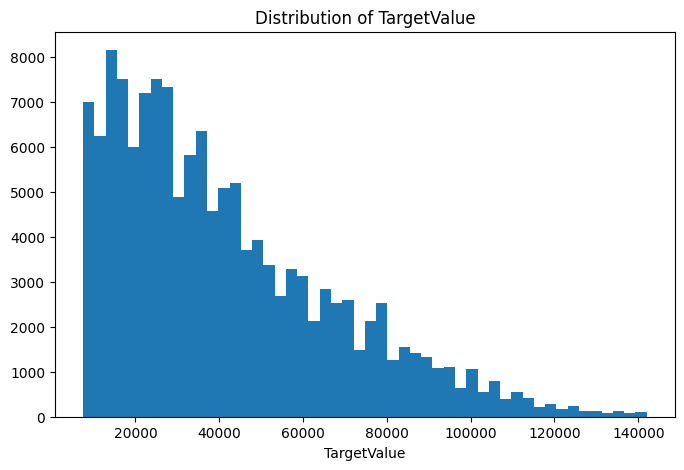

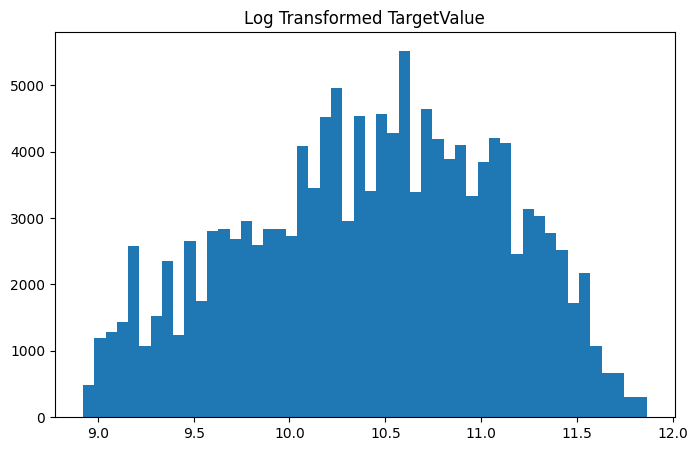

In [5]:
#Target Distribution:
plt.figure(figsize=(8,5))
plt.hist(train["TargetValue"], bins=50)
plt.title("Distribution of TargetValue")
plt.xlabel("TargetValue")
plt.show()
plt.figure(figsize=(8,5))
plt.hist(np.log1p(train["TargetValue"]), bins=50)
plt.title("Log Transformed TargetValue")
plt.show()

# Target Distribution:

**Observation:**
The first histogram shows that the TargetValue is right-skewed, where most equipment has lower selling prices and only a few have very high prices. After applying the log transformation (log1p), the distribution becomes much more balanced and closer to a normal distribution. This reduces the effect of extreme values (outliers) and makes the target easier for the model to learn.

**Interpretation:**
From this analysis, I learned that the original target variable is highly skewed and may negatively affect model performance. Therefore, I applied np.log1p() to the target before training and converted the predictions back using np.expm1() after prediction. This transformation improves model stability, reduces the influence of outliers, and helps CatBoost, LightGBM, and XGBoost achieve better prediction accuracy

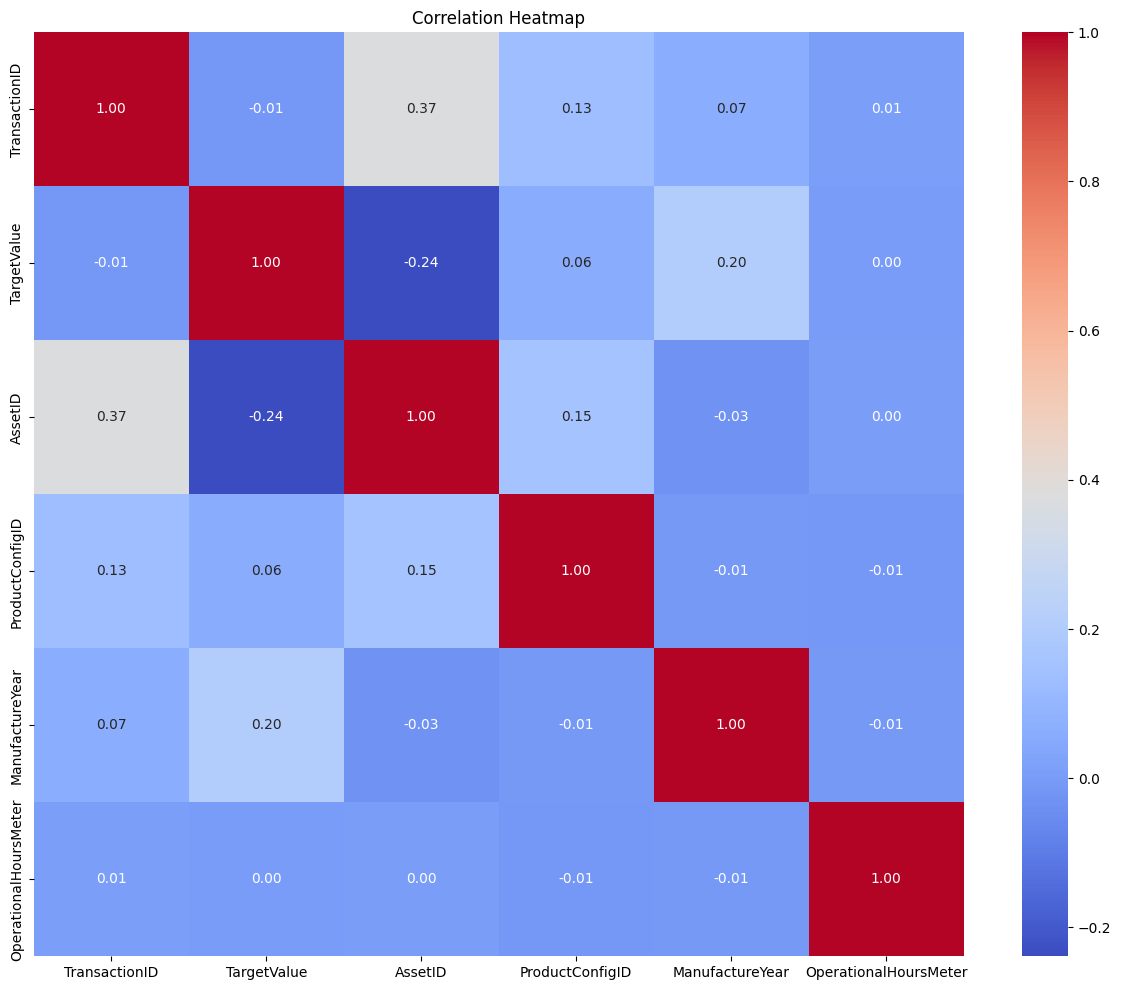

In [6]:
#Correlation Analysis:
numeric_cols = train.select_dtypes(include=np.number)

plt.figure(figsize=(15,12))
sns.heatmap(numeric_cols.corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Correlation Analysis:

**Observation:**
The correlation heatmap shows the relationship between numerical features and the target variable. Most features have weak to moderate correlations with TargetValue, with ManufactureYear showing a slight positive correlation (0.20) and AssetID showing a weak negative correlation (-0.24). This indicates that no single feature alone strongly determines the selling price.

**Interpretation:**
From this analysis, I learned that predicting equipment price depends on the combined effect of multiple features rather than a single variable. This supports the use of advanced ensemble models like CatBoost, LightGBM, and XGBoost, which can learn complex relationships between multiple features. The correlation analysis also helped verify that there was no severe multicollinearity among the numerical features, making the dataset suitable for model training.

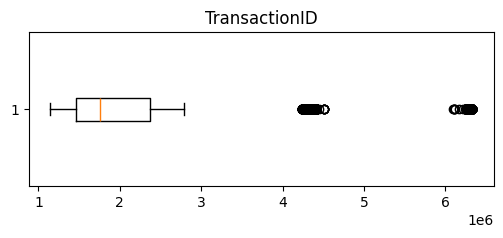

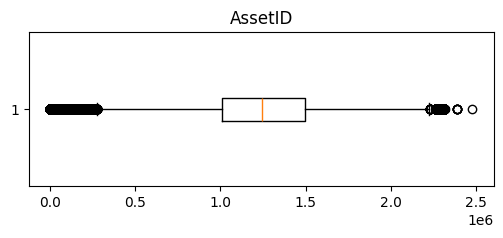

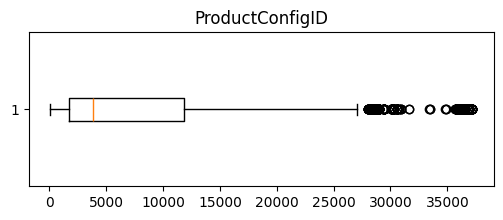

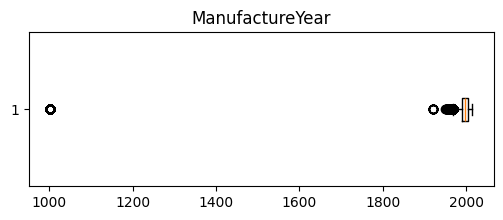

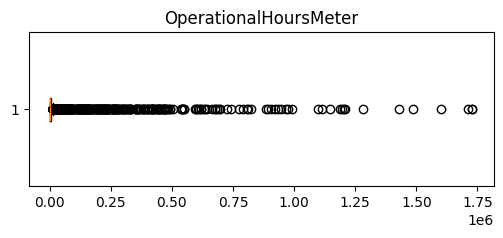

In [7]:
#Distribution and Outlier Analysis of Numerical Features:
num_cols = train.select_dtypes(include=np.number).columns

for col in num_cols:
    if col != "TargetValue":
        plt.figure(figsize=(6,2))
        plt.boxplot(train[col].dropna(), vert=False)
        plt.title(col)
        plt.show()

# Distribution and Outlier Analysis of Numerical Features:

**Observation:**
The box plots show the distribution of numerical features and highlight the presence of outliers. Features such as OperationalHoursMeter, ProductConfigID, and TransactionID contain several extreme values, while ManufactureYear has a few abnormal values around 1000, which appear to be invalid data entries. This indicates that the dataset contains unusual observations that require preprocessing.

**Interpretation:**
From this analysis, I learned that the dataset contains both genuine extreme values and invalid values that could affect model performance. Based on these findings, I replaced invalid ManufactureYear values (1000 and 1001) with NaN and created new features such as AssetAge and HoursPerYear to better represent the data. Since CatBoost, LightGBM, and XGBoost are tree-based models, they can naturally handle many outliers without requiring their removal, making them suitable for this dataset.

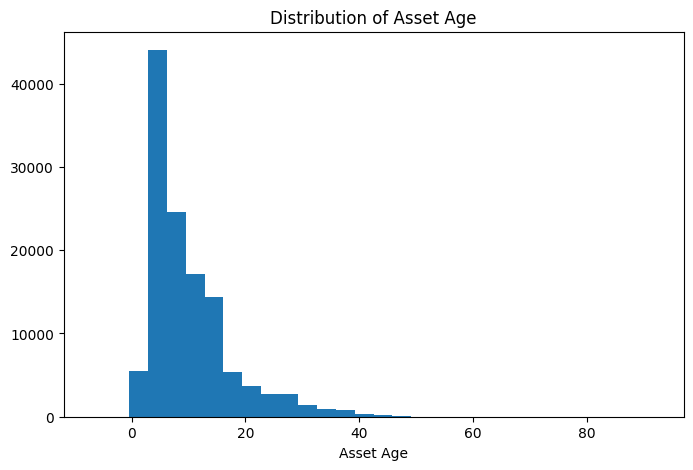

In [8]:
#Asset age distribution:
temp = train.copy()
temp["TransactionDate"] = pd.to_datetime(temp["TransactionDate"])
temp["SaleYear"] = temp["TransactionDate"].dt.year
temp["ManufactureYear"] = temp["ManufactureYear"].replace([1000,1001],np.nan)
temp["AssetAge"] = temp["SaleYear"] - temp["ManufactureYear"]

plt.figure(figsize=(8,5))
plt.hist(temp["AssetAge"].dropna(), bins=30)
plt.title("Distribution of Asset Age")
plt.xlabel("Asset Age")
plt.show()

# Asset age distribution:

**Observation:**
The histogram shows that most equipment assets are between 0 and 15 years old, with the frequency gradually decreasing as asset age increases. The distribution is right-skewed, indicating that older equipment is less common in the dataset. Only a small number of assets are more than 40 years old.

**Interpretation:**
From this analysis, I learned that AssetAge is an important engineered feature that captures the age of the equipment at the time of sale. Since equipment value generally decreases with age, this feature provides useful information for predicting the selling price. Including AssetAge helps CatBoost, LightGBM, and XGBoost identify the relationship between equipment age and market value, improving prediction accuracy.

Text(0, 0.5, 'TargetValue')

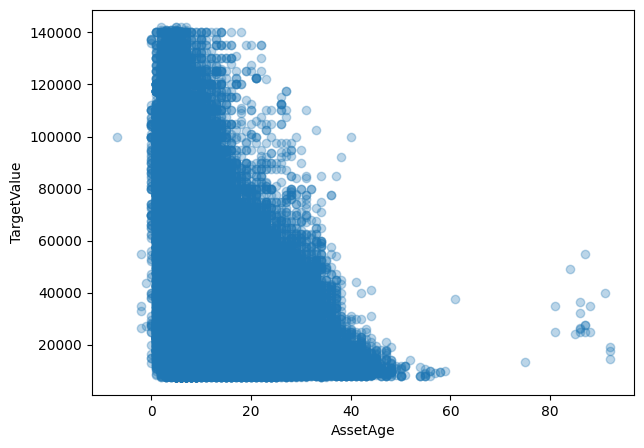

In [9]:
#Asset age and target value:
plt.figure(figsize=(7,5))
plt.scatter(temp["AssetAge"],train["TargetValue"],alpha=0.3)
plt.xlabel("AssetAge")
plt.ylabel("TargetValue")


# Asset age vs target value:

**Observation:**
The scatter plot shows the relationship between AssetAge and TargetValue. Most newer assets (lower AssetAge) have a wider range of selling prices, including many high-value sales, while older assets generally have lower selling prices. This indicates a negative relationship between asset age and equipment value.

**Interpretation:**
From this analysis, I learned that AssetAge is an important predictor of selling price, as equipment tends to lose value as it becomes older. This justifies creating AssetAge as a feature during feature engineering. The machine learning models use this relationship, along with other features, to better estimate the selling price and improve prediction accuracy.

Tuning CatBoost...
Best CatBoost Parameters: {'learning_rate': 0.03, 'iterations': 1000, 'depth': 10}
Best Cross Validation Score: 0.24130450896859076
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018268 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2576
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 52
[LightGBM] [Info] Start training from score 10.424734
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CatBoost RMSLE : 0.23673322779443132
LightGBM RMSLE: 0.21890910570169414
XGBoost RMSLE : 0.21934938196974346
Validation RMSLE: 0.22037804746653433
Model Comparison
----------------------------------------------------------------------
CatBoost : 0.23673322779443132
LightGBM : 0.21890910570169414
XGBoost  : 0.21934938196974346
Ensemble : 0.22037804746653433

Best Performing Model: LightGBM


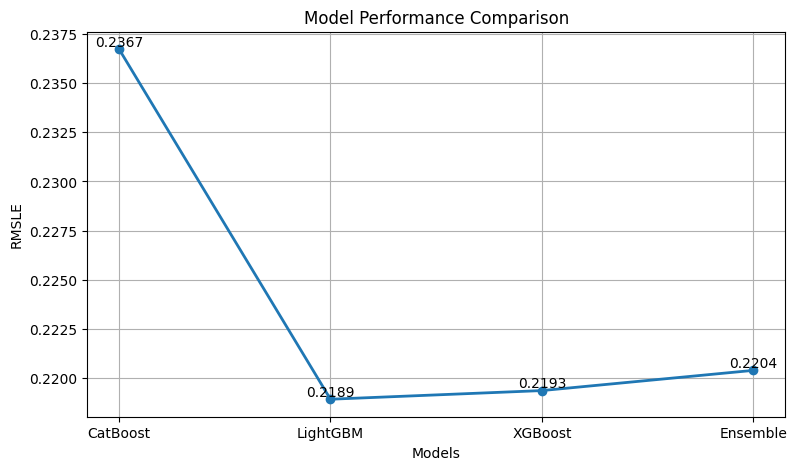

In [10]:
TRAIN_PATH="/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
TEST_PATH="/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv"

train=pd.read_csv(TRAIN_PATH,low_memory=False)
test=pd.read_csv(TEST_PATH,low_memory=False)

for df in [train,test]:
    df["TransactionDate"]=pd.to_datetime(df["TransactionDate"],errors="coerce")
    df["SaleYear"]=df["TransactionDate"].dt.year
    df["SaleMonth"]=df["TransactionDate"].dt.month
    df["SaleQuarter"]=df["TransactionDate"].dt.quarter
    df["SaleDay"]=df["TransactionDate"].dt.day
    df["SaleWeekday"]=df["TransactionDate"].dt.weekday
    df["ManufactureYear"]=df["ManufactureYear"].replace([1000,1001],np.nan)
    df["AssetAge"]=df["SaleYear"]-df["ManufactureYear"]
    if "OperationalHoursMeter" in df.columns:
        df["HasOperationalHours"]=df["OperationalHoursMeter"].notna().astype(int)
        df["HoursPerYear"]=df["OperationalHoursMeter"]/(df["AssetAge"]+1)
    if "Spec_FullDescriptor" in df.columns:
        df["DescriptorLength"]=df["Spec_FullDescriptor"].fillna("").astype(str).str.len()

TARGET="TargetValue"
X=train.drop(columns=[TARGET])
y=np.log1p(train[TARGET])

X=X.drop(columns=["TransactionDate"])
test=test.drop(columns=["TransactionDate"])

X_train,X_valid,y_train,y_valid=train_test_split(X,y,test_size=0.2,random_state=42)

#Numerical and Categorical Columns
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

#Numerical Pipeline
num_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

#Categorical Pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant",fill_value="Missing")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))])

#Combine Both
preprocessor = ColumnTransformer([("num", num_pipeline, num_cols),("cat", cat_pipeline, cat_cols)])

# Apply Pipeline
# Validation
X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)

# Final training
preprocessor.fit(X)
X_processed = preprocessor.transform(X)
test_processed = preprocessor.transform(test)

#Hyperparameter Tuning for CatBoost
params = {"depth": [6, 8, 10],
    "learning_rate": [0.03, 0.05],
    "iterations": [500, 1000]}

search = RandomizedSearchCV(CatBoostRegressor(loss_function="RMSE",random_seed=42,verbose=False),
    param_distributions=params,
    n_iter=4,
    cv=3,                     
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1)

print("Tuning CatBoost...")
search.fit(X_train, y_train)
cat_model = search.best_estimator_

print("Best CatBoost Parameters:", search.best_params_)
print("Best Cross Validation Score:", -search.best_score_)

#LightGBM
lgb_model = LGBMRegressor(n_estimators=1000,learning_rate=0.05,num_leaves=127,subsample=0.8,
    colsample_bytree=0.8,random_state=42)

#XGBoost
xgb_model = XGBRegressor(n_estimators=1000,learning_rate=0.05,max_depth=8,subsample=0.8,
    colsample_bytree=0.8,objective="reg:squarederror",tree_method="hist",random_state=42)

print("Training LightGBM...")
lgb_model.fit(X_train, y_train)
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

#Validation
cat_pred = cat_model.predict(X_valid)
lgb_pred = lgb_model.predict(X_valid)
xgb_pred = xgb_model.predict(X_valid)

cat_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_valid),np.expm1(cat_pred)))
lgb_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_valid),np.expm1(lgb_pred)))
xgb_rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_valid),np.expm1(xgb_pred)))

print("CatBoost RMSLE :", cat_rmsle)
print("LightGBM RMSLE:", lgb_rmsle)
print("XGBoost RMSLE :", xgb_rmsle)

pred = (0.3 * cat_pred +0.5 * lgb_pred +0.2 * xgb_pred)
rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_valid),np.expm1(pred)))

print("Validation RMSLE:", rmsle)

print("Model Comparison")
print("-"*70)
print("CatBoost :", cat_rmsle)
print("LightGBM :", lgb_rmsle)
print("XGBoost  :", xgb_rmsle)
print("Ensemble :", rmsle)

best_model = min(
    {
        "CatBoost": cat_rmsle,
        "LightGBM": lgb_rmsle,
        "XGBoost": xgb_rmsle,
        "Ensemble": rmsle
    },
    key=lambda x: {
        "CatBoost": cat_rmsle,
        "LightGBM": lgb_rmsle,
        "XGBoost": xgb_rmsle,
        "Ensemble": rmsle
    }[x]
)

print("\nBest Performing Model:", best_model)

#plot for comparison
models = ["CatBoost", "LightGBM", "XGBoost", "Ensemble"]
rmsle_scores = [cat_rmsle, lgb_rmsle, xgb_rmsle, rmsle]

plt.figure(figsize=(9, 5))
plt.plot(models, rmsle_scores, marker="o", linewidth=2)
for i, score in enumerate(rmsle_scores):
    plt.text(i, score, f"{score:.4f}", ha="center", va="bottom")

plt.xlabel("Models")
plt.ylabel("RMSLE")
plt.title("Model Performance Comparison")
plt.grid(True)
plt.show()

# Model Performance Comparison:
**Observation:**
The plot compares the RMSLE values of CatBoost, LightGBM, XGBoost, and the Ensemble model. LightGBM has the lowest RMSLE value of 0.2189, followed closely by XGBoost with 0.2193. The Ensemble model has an RMSLE of 0.2204, while CatBoost has the highest RMSLE of 0.2367. Since a lower RMSLE indicates lower prediction error, LightGBM shows the lowest error among the models evaluated.

**Interpretation:**
From this analysis, I learned that LightGBM performed best on the validation data, achieving the lowest RMSLE of 0.2189. XGBoost also produced a similar error, while CatBoost showed a comparatively higher prediction error. Although the Ensemble model combines predictions from multiple models, its RMSLE (0.2204) was slightly higher than LightGBM. Therefore, LightGBM was selected as the final model because it provided the lowest RMSLE and demonstrated better predictive performance on the given dataset.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2594
[LightGBM] [Info] Number of data points in the train set: 138701, number of used features: 52
[LightGBM] [Info] Start training from score 10.424111


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   TransactionID   TargetValue
0        1139307  69994.301976
1        1139419  67788.757149
2        1139482  31675.883257
3        1139522  20776.431840
4        1139684  13178.436585
submission.csv created successfully


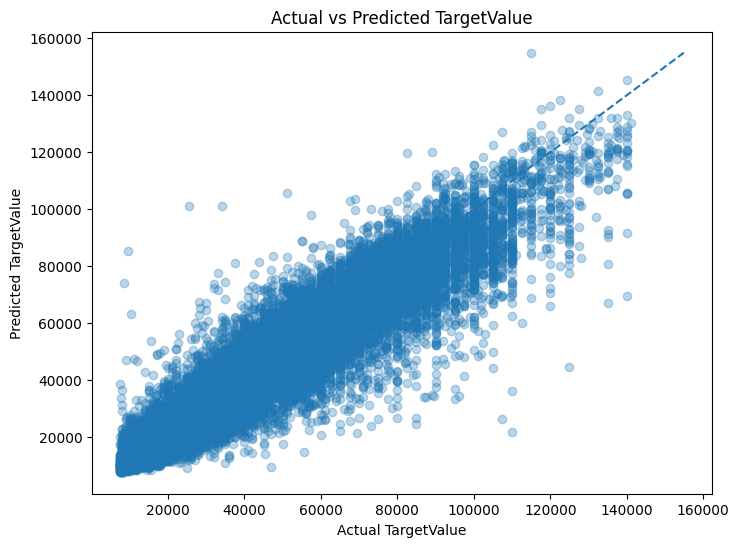

In [11]:
#Train on Full Dataset
cat_model.fit(X_processed,y)
lgb_model.fit(X_processed,y)
xgb_model.fit(X_processed,y)

cat_test = cat_model.predict(test_processed)
lgb_test = lgb_model.predict(test_processed)
xgb_test = xgb_model.predict(test_processed)

tp = (0.3 * cat_test +0.5 * lgb_test +0.2 * xgb_test)

submission = pd.DataFrame({"TransactionID": test["TransactionID"],"TargetValue": np.expm1(tp)})
submission.to_csv("/kaggle/working/submission.csv", index=False)

print(submission.head())
print("submission.csv created successfully")

#plot for actual and predicted:
plt.figure(figsize=(8, 6))
plt.scatter(np.expm1(y_valid),np.expm1(pred),alpha=0.3)
plt.xlabel("Actual TargetValue")
plt.ylabel("Predicted TargetValue")
plt.title("Actual vs Predicted TargetValue")

# Perfect prediction line
min_value = min(np.expm1(y_valid).min(),np.expm1(pred).min())
max_value = max(np.expm1(y_valid).max(),np.expm1(pred).max())
plt.plot([min_value, max_value],[min_value, max_value],linestyle="--")
plt.show()

# Actual vs Predicted TargetValue

**Observation:**
The scatter plot shows a strong positive relationship between the actual and predicted TargetValue. Most points are concentrated around the upward-sloping reference line, indicating that the predicted values generally follow the actual selling prices. However, there is some spread around the line, particularly at higher target values, along with a few noticeable outliers.

**Interpretation:**
From this analysis, I learned that the machine learning model is able to capture the overall relationship between the input features and the equipment selling price. The close alignment of most predictions with the actual values indicates that the model provides reasonably accurate predictions across a wide range of TargetValue. The deviations and outliers show that prediction errors still occur for some equipment, especially at higher values. Overall, this plot provides a visual assessment of the model's prediction performance after fitting.